# GPT-2 + Vision (Stackformer V2) — 1-Stage On-the-Fly OO Training Notebook (NaN-Stable)

This notebook implements a modular **Object-Oriented (OO) 1-Stage training architecture** for **GPT2VL** with comprehensive numerical stability safeguards against NaN loss/alpha explosion on NVIDIA T4 GPUs:

- **1-Stage On-the-Fly ViT Feature Extraction**: Bypasses heavy offline feature caching on disk. Images from `Trickxter/COCO2017-captions` are transformed and passed directly to a frozen **ViT-B/16** vision encoder on-the-fly during each training batch forward pass.
- **Numerical Stability Safeguards**: Gradient unscaling + norm clipping (`max_norm=1.0`), non-finite loss batch dropping (`torch.isfinite`), caption fallback (`"a photo"`), gating alpha bounds (`[-1.0, 1.0]`), and PyTorch 2.x `torch.amp.GradScaler('cuda')` API.
- **Object-Oriented Design**: Encapsulates components into clean classes (`GPT2VLTrainer`, `CheckpointManager`, `OnTheFlyVisionTextDataset`, `CaptionEvaluator`).
- **Exact Resumable Checkpointing & Google Drive Sync**: `CheckpointManager` handles saving/restoring model trainable weights (`safetensors`), optimizer/scheduler/scaler states, epoch, global step, and RNG states. On resume, `GPT2VLTrainer` fast-forwards to the exact batch where training paused.


In [1]:
# Install dependencies cleanly into Colab environment
!pip install -q --no-deps datasets pycocoevalcap safetensors
!git clone https://github.com/stackformer-labs/Stackformer.git || true


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.3/104.3 MB 7.6 MB/s eta 0:00:00
Cloning into 'Stackformer'...
remote: Enumerating objects: 1663, done.
remote: Counting objects: 100% (571/571), done.
remote: Compressing objects: 100% (396/396), done.
remote: Total 1663 (delta 288), reused 364 (delta 165), pack-reused 1092 (from 2)
Receiving objects: 100% (1663/1663), 3.01 MiB | 6.32 MiB/s, done.
Resolving deltas: 100% (870/870), done.


### Root-Cause Fix for NaN / Inf Loss: FP32-Stable LayerNorm/RMSNorm

**Diagnosis.** The cloned `stackformer` package's `LayerNorm`/`RMSNorm` (used ~24x in the frozen GPT-2 backbone, plus in every gated cross-attention block and the perceiver resampler) compute `mean`/`var`/`sqrt` with plain tensor ops. These ops are **not** on PyTorch autocast's fp32-safe list, so under `torch.amp.autocast('cuda', dtype=torch.float16)` they execute in fp16. GPT-2's residual stream routinely reaches activation magnitudes in the hundreds by the later layers -- squaring a value like `~300` inside `var()` already exceeds fp16's `~65504` max and silently overflows to `inf`. That `inf` poisons the row's `mean`/`var`, `x - mean` becomes `NaN`, and it propagates through every downstream layer, surfacing as the `NaN`/`Inf` training loss.

**Fix.** We overwrite `Stackformer/stackformer/modules/Normalization.py` on disk, right after cloning and before the editable install, with a version whose `forward()` always upcasts to float32 for the normalization math and casts back down afterward -- exactly how PyTorch's built-in `torch.nn.LayerNorm` is special-cased by autocast. Patching the file (rather than monkey-patching the class at runtime after import) means the fix is baked into the installed package itself, so it can't accidentally be skipped by an import-order change or a fresh `pip install -e` later in the notebook.

In [2]:
# Overwrite the cloned repo's Normalization.py with an FP32-stable version *before*
# `pip install -e ./Stackformer` runs, so the fix is part of the installed package.
import os

_fixed_normalization_src = '"""Normalization layers for StackFormer blocks.\n\nProvides per-token normalization operators used in Transformer architectures:\n- LayerNorm (mean + variance normalization with affine scale/bias)\n- RMSNorm (Root Mean Square normalization with affine scale only)\n\nEquations:\n- LayerNorm: y = gamma * (x - mean(x)) / sqrt(var(x) + eps) + beta\n- RMSNorm:   y = gamma * x / (sqrt(mean(x^2)) + eps)\n\nNumerical stability:\n- Both layers upcast the input to float32 for the mean/variance/sqrt math and cast\n  the result back to the input\'s original dtype before returning. This mirrors how\n  PyTorch\'s built-in `torch.nn.LayerNorm` is special-cased by `torch.autocast`\n  (always executed in float32 internally). Without this upcast, plain tensor ops\n  like `.var()` and `.sqrt()` are NOT protected by autocast, so under fp16 mixed\n  precision they run in fp16. Deep pre-norm transformer stacks routinely produce\n  activations with magnitude in the hundreds by their later layers, and squaring\n  values like that inside `var()` already exceeds fp16\'s ~65504 max, silently\n  overflowing to `inf`. That `inf` poisons the row\'s mean/variance, `x - mean`\n  becomes `NaN`, and it propagates through every downstream layer -- surfacing as\n  `NaN`/`Inf` training loss. Upcasting internally closes this failure mode while\n  keeping the public dtype contract (and memory footprint) of each call unchanged.\n"""\n\nfrom __future__ import annotations\n\nimport torch\nimport torch.nn as nn\n\n\nclass LayerNorm(nn.Module):\n    """Layer normalization over the last tensor dimension.\n\n    Computation:\n        y = gamma * (x - mean(x)) / sqrt(var(x) + eps) + beta\n\n    The mean/variance/normalization math is always performed in float32\n    internally (regardless of the input\'s dtype) and cast back to the input\'s\n    original dtype before returning, to avoid fp16 overflow in `var()`/`sqrt()`\n    on large-magnitude activations. See module docstring for details.\n\n    Constructor args:\n        embed_dim (int): Normalized feature size ``C``.\n        eps (float, default=1e-5): Numerical stability constant.\n        device (torch.device | str | None, default=None): Target compute device.\n        dtype (torch.dtype | None, default=None): Target data type.\n\n    Learnable parameters:\n        - weight (gamma): Scale parameter of shape ``(C,)``.\n        - bias (beta): Shift parameter of shape ``(C,)``.\n\n    Forward args:\n        x (torch.Tensor): Input tensor of shape ``(B, T, C)``.\n\n    Returns:\n        torch.Tensor: Normalized output tensor of shape ``(B, T, C)``, same dtype as input.\n\n    Example:\n        >>> norm = LayerNorm(embed_dim=256, eps=1e-5)\n        >>> x = torch.randn(4, 32, 256)\n        >>> y = norm(x)\n        >>> y.shape\n        torch.Size([4, 32, 256])\n    """\n\n    def __init__(\n        self,\n        embed_dim: int,\n        device: torch.device | str | None = None,\n        dtype: torch.dtype | None = None,\n        eps: float = 1e-5,\n    ) -> None:\n        super().__init__()\n        self.eps = eps\n        factory_kwargs = {"device": device, "dtype": dtype}\n        self.weight = nn.Parameter(torch.ones(embed_dim, **factory_kwargs))  # gamma\n        self.bias = nn.Parameter(torch.zeros(embed_dim, **factory_kwargs))  # beta\n\n    def forward(self, x: torch.Tensor) -> torch.Tensor:\n        # x: (B, T, C)\n        # Upcast to fp32 for the reduction/normalization math so this is safe under\n        # fp16 autocast, then cast back down -- a drop-in replacement for callers.\n        orig_dtype = x.dtype\n        x32 = x.float()\n        mean = x32.mean(dim=-1, keepdim=True)\n        var = x32.var(dim=-1, keepdim=True, unbiased=False)\n        normalized_x = (x32 - mean) / torch.sqrt(var + self.eps)\n        output = self.weight.float() * normalized_x + self.bias.float()\n        return output.to(orig_dtype)  # (B, T, C)\n\n\nclass RMSNorm(nn.Module):\n    """Root Mean Square Normalization (RMSNorm) over the last tensor dimension.\n\n    Computation:\n        y = gamma * x / (sqrt(mean(x^2)) + eps)\n\n    The RMS/normalization math is always performed in float32 internally\n    (regardless of the input\'s dtype) and cast back to the input\'s original\n    dtype before returning, for the same fp16-overflow reasons as `LayerNorm`\n    above -- squaring large activations in fp16 can overflow before the sqrt\n    is ever taken.\n\n    Constructor args:\n        embed_dim (int): Feature dimension size ``C``.\n        eps (float, default=1e-5): Numerical stability constant.\n        device (torch.device | str | None, default=None): Target compute device.\n        dtype (torch.dtype | None, default=None): Target data type.\n\n    Learnable parameters:\n        - weight (gamma): Scale parameter of shape ``(C,)``.\n\n    Forward args:\n        x (torch.Tensor): Input tensor of shape ``(B, T, C)``.\n\n    Returns:\n        torch.Tensor: Normalized output tensor of shape ``(B, T, C)``, same dtype as input.\n\n    Example:\n        >>> norm = RMSNorm(embed_dim=256)\n        >>> x = torch.randn(4, 32, 256)\n        >>> y = norm(x)\n        >>> y.shape\n        torch.Size([4, 32, 256])\n    """\n\n    def __init__(\n        self,\n        embed_dim: int,\n        device: torch.device | str | None = None,\n        dtype: torch.dtype | None = None,\n        eps: float = 1e-5,\n    ) -> None:\n        super().__init__()\n        self.eps = eps\n        factory_kwargs = {"device": device, "dtype": dtype}\n        self.weight = nn.Parameter(torch.ones(embed_dim, **factory_kwargs))  # gamma\n\n    def forward(self, x: torch.Tensor) -> torch.Tensor:\n        # x: (B, T, C)\n        orig_dtype = x.dtype\n        x32 = x.float()\n        rms = (x32.pow(2).mean(-1, keepdim=True) + self.eps).sqrt()\n        normalized_x = x32 / rms\n        output = self.weight.float() * normalized_x\n        return output.to(orig_dtype)  # (B, T, C)\n\n\n# Backward-compat aliases\nLayerNormalization = LayerNorm\nRMSNormalization = RMSNorm\n'

_norm_path = "Stackformer/stackformer/modules/Normalization.py"
if os.path.exists(_norm_path):
    with open(_norm_path, "w") as _f:
        _f.write(_fixed_normalization_src)
    print(f"Patched {_norm_path} with FP32-stable LayerNorm/RMSNorm.")
else:
    print(f"WARNING: {_norm_path} not found -- clone step may have failed.")


Patched Stackformer/stackformer/modules/Normalization.py with FP32-stable LayerNorm/RMSNorm.


In [3]:
# Guard flex_attention import in cloned Stackformer for PyTorch < 2.5 compatibility in Colab
!python -c "import os; def patch(p, t, r): (open(p, 'w').write(open(p).read().replace(t, r)) if os.path.exists(p) and t in open(p).read() else None); patch('Stackformer/stackformer/modules/masks.py', 'from torch.nn.attention.flex_attention import (\n    BlockMask,\n    and_masks,\n    create_block_mask,\n    noop_mask,\n    or_masks,\n)', 'try:\n    from torch.nn.attention.flex_attention import (\n        BlockMask,\n        and_masks,\n        create_block_mask,\n        noop_mask,\n        or_masks,\n    )\nexcept ImportError:\n    BlockMask = and_masks = create_block_mask = noop_mask = or_masks = None'); patch('Stackformer/stackformer/modules/attention_engine.py', 'from torch.nn.attention.flex_attention import flex_attention', 'try:\n    from torch.nn.attention.flex_attention import flex_attention\nexcept ImportError:\n    flex_attention = None')"
!pip install -q --no-deps -e ./Stackformer


  File "<string>", line 1
    import os; def patch(p, t, r): (open(p, 'w').write(open(p).read().replace(t, r)) if os.path.exists(p) and t in open(p).read() else None); patch('Stackformer/stackformer/modules/masks.py', 'from torch.nn.attention.flex_attention import (\n    BlockMask,\n    and_masks,\n    create_block_mask,\n    noop_mask,\n    or_masks,\n)', 'try:\n    from torch.nn.attention.flex_attention import (\n        BlockMask,\n        and_masks,\n        create_block_mask,\n        noop_mask,\n        or_masks,\n    )\nexcept ImportError:\n    BlockMask = and_masks = create_block_mask = noop_mask = or_masks = None'); patch('Stackformer/stackformer/modules/attention_engine.py', 'from torch.nn.attention.flex_attention import flex_attention', 'try:\n    from torch.nn.attention.flex_attention import flex_attention\nexcept ImportError:\n    flex_attention = None')
               ^^^
SyntaxError: invalid syntax
  Installing build dependencies ... done
  Checking if build backend supp

In [4]:
import os
import sys

# Dynamically insert Stackformer repo directory into sys.path
for sf_path in ["./Stackformer", "/content/Stackformer"]:
    if os.path.exists(sf_path) and os.path.abspath(sf_path) not in sys.path:
        sys.path.insert(0, os.path.abspath(sf_path))

import time
from tqdm.auto import tqdm
import math
import re
import json
import random
import unicodedata
import glob
import shutil
from typing import Optional, Dict, List, Tuple

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision.models import vit_b_16, ViT_B_16_Weights
from torchvision import transforms

from datasets import load_dataset
from transformers import GPT2TokenizerFast, GPT2LMHeadModel
from PIL import Image as PILImage
from safetensors.torch import save_file, load_file

import stackformer.modules.Attention as sf_attn
import stackformer.modules.attention_engine as sf_engine
from stackformer.modules.Attention import Cross_MultiHead_Attention
from stackformer.modules.Normalization import LayerNormalization
from stackformer.modules.Feed_forward import FF_GELU
from stackformer.models.gpt import GPT_2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


device: cuda
GPU: Tesla T4


## 2. Verify and Patch `stackformer` Attention Runtime


In [5]:
def causal_mask_is_correct():
    torch.manual_seed(0)
    attn = sf_attn.Multi_Head_Attention(embed_dim=8, num_heads=2, qkv_bias=True, mask_type=["causal"])
    attn.eval()
    x = torch.randn(1, 4, 8)
    with torch.no_grad():
        out1 = attn(x, mask=True)
        x2 = x.clone()
        x2[0, -1] += 100.0
        out2 = attn(x2, mask=True)
    return torch.allclose(out1[:, 0], out2[:, 0], atol=1e-4, rtol=1e-4)

def causal_mask_position0_strict():
    """Stricter test: position-0 output must be completely unaffected by ANY change
    to tokens at positions 1+, regardless of magnitude."""
    torch.manual_seed(42)
    attn = sf_attn.Multi_Head_Attention(embed_dim=8, num_heads=2, qkv_bias=True, mask_type=["causal"])
    attn.eval()
    x = torch.randn(1, 6, 8)
    with torch.no_grad():
        out_base = attn(x, mask=True)
        # Randomly mutate ALL positions except 0
        x_mut = x.clone()
        x_mut[0, 1:] = torch.randn_like(x_mut[0, 1:]) * 1000.0
        out_mut = attn(x_mut, mask=True)
    return torch.allclose(out_base[0, 0], out_mut[0, 0], atol=1e-4, rtol=1e-4)

print("Before patch:", causal_mask_is_correct())
print("Strict pos-0 test (pre-patch):", causal_mask_position0_strict())

bug_present = not causal_mask_is_correct()
if bug_present:
    def _run_sdpa_fixed(q, k, v, attn_mask, dropout_p=0.0, is_causal=False, scale=None, enable_gqa=False):
        if attn_mask is not None and attn_mask.dtype == torch.bool:
            attn_mask = ~attn_mask
        kwargs = {"attn_mask": attn_mask, "dropout_p": dropout_p, "is_causal": is_causal}
        if scale is not None: kwargs["scale"] = scale
        if enable_gqa: kwargs["enable_gqa"] = enable_gqa
        return F.scaled_dot_product_attention(q, k, v, **kwargs)
    sf_engine._run_sdpa = _run_sdpa_fixed

print("Causal masking bug present:", bug_present, "-> patched:", bug_present)
assert causal_mask_is_correct(), "Basic causal mask check failed post-patch!"
assert causal_mask_position0_strict(), "Strict pos-0 causal mask check failed post-patch!"
print("Strict pos-0 test (post-patch):", causal_mask_position0_strict())

def _patch_attention_dropout_respects_eval():
    cls_names = [
        "Self_Attention", "Multi_Head_Attention", "Multi_Head_Attention_With_RoPE",
        "Cross_MultiHead_Attention", "Multi_query_Attention", "Multi_query_Attention_With_RoPE",
        "Group_query_Attention", "Group_query_Attention_With_RoPE",
    ]
    patched = []
    for name in cls_names:
        cls = getattr(sf_attn, name, None)
        if cls is None:
            continue
        orig_forward = cls.forward

        def make_wrapper(orig_forward):
            def wrapper(self, *args, **kwargs):
                old_p = self.dropout_p
                if not self.training:
                    self.dropout_p = 0.0
                try:
                    return orig_forward(self, *args, **kwargs)
                finally:
                    self.dropout_p = old_p
            return wrapper

        cls.forward = make_wrapper(orig_forward)
        patched.append(name)
    return patched

patched_classes = _patch_attention_dropout_respects_eval()
print("Patched dropout-vs-eval behavior for:", patched_classes)


Before patch: True
Strict pos-0 test (pre-patch): True
Causal masking bug present: False -> patched: False
Strict pos-0 test (post-patch): True
Patched dropout-vs-eval behavior for: ['Self_Attention', 'Multi_Head_Attention', 'Multi_Head_Attention_With_RoPE', 'Cross_MultiHead_Attention', 'Multi_query_Attention', 'Multi_query_Attention_With_RoPE', 'Group_query_Attention', 'Group_query_Attention_With_RoPE']


## 2b. Verify the NaN / Inf Fix Took Effect

`LayerNormalization`/`RMSNormalization` were already imported above from the **patched** `stackformer.modules.Normalization` (fixed on disk before the editable install -- see the fix cell right after the dependency install). No runtime monkey-patching needed here; this cell just proves the fix is live by re-running the exact overflow scenario that used to break the old implementation.

In [6]:
# Sanity check: realistic fp16 activation magnitudes (well within what a 12-layer
# pre-norm GPT-2 residual stream produces) used to overflow the old LayerNorm's
# fp16 var()/sqrt() math. Confirm the patched, FP32-internal version stays finite.
torch.manual_seed(0)
_gpt2_small_embed_dim = 768  # matches CFG["embed_dim"], defined a couple cells below
_x_probe = (torch.randn(4, 8, _gpt2_small_embed_dim) * 300).half()
if device.type == "cuda":
    _x_probe = _x_probe.to(device)
_probe_ln = LayerNormalization(_gpt2_small_embed_dim, device=_x_probe.device, dtype=torch.float16)
_out_probe = _probe_ln(_x_probe)
assert torch.isfinite(_out_probe).all(), (
    "LayerNormalization is still producing NaN/Inf on large fp16 activations -- "
    "the Normalization.py patch did not take effect (check cell output above)."
)
print("LayerNormalization output finite under realistic large-magnitude fp16 input:",
      torch.isfinite(_out_probe).all().item())


LayerNormalization output finite under realistic large-magnitude fp16 input: True


## 3. Configuration


In [7]:
CFG = {
    # Dataset & Storage
    "dataset_name": "Trickxter/COCO2017-captions",
    "checkpoint_dir": "./gpt2vl_checkpoints",
    "gdrive_checkpoint_dir": "/content/drive/MyDrive/GPT2VL_Checkpoints",

    # GPT-2 Small Backbone
    "vocab_size": 50258,
    "embed_dim": 768,
    "num_layers": 12,
    "num_heads": 12,
    "hidden_dim": 3072,
    "context_length": 128,
    "dropout": 0.1,
    "qkv_bias": True,

    # Vision & Multimodal Gated Cross-Attn
    "vision_dim": 768,
    "cross_attention_pos": [3, 6, 9],
    "num_visual_tokens": 64,    # 64 latent tokens
    "perceiver_depth": 2,       # 2 perceiver layers
    "perceiver_heads": 8,       # 8 perceiver heads

    # Training Setup & Scheduler
    "batch_size": 32,
    "grad_accum_steps": 2,      # Effective batch size = 32
    "learning_rate": 1e-4,
    "min_learning_rate": 1e-6,
    "warmup_pct": 0.05,         # 5% warmup steps
    "weight_decay": 0.01,
    "num_epochs": 10,
    "max_grad_norm": 1.0,       # Gradient clipping norm to prevent FP16 overflow
    "alpha_clamp": 1.0,         # Alpha gating parameter bounds [-1.0, 1.0]
    "time_budget_minutes": 270, # 4.5 hours stop trigger
    "amp_dtype": "fp16" if torch.cuda.is_available() else "fp32",
}
print(CFG)


{'dataset_name': 'Trickxter/COCO2017-captions', 'checkpoint_dir': './gpt2vl_checkpoints', 'gdrive_checkpoint_dir': '/content/drive/MyDrive/GPT2VL_Checkpoints', 'vocab_size': 50258, 'embed_dim': 768, 'num_layers': 12, 'num_heads': 12, 'hidden_dim': 3072, 'context_length': 128, 'dropout': 0.1, 'qkv_bias': True, 'vision_dim': 768, 'cross_attention_pos': [3, 6, 9], 'num_visual_tokens': 64, 'perceiver_depth': 2, 'perceiver_heads': 8, 'batch_size': 32, 'grad_accum_steps': 2, 'learning_rate': 0.0001, 'min_learning_rate': 1e-06, 'warmup_pct': 0.05, 'weight_decay': 0.01, 'num_epochs': 10, 'max_grad_norm': 1.0, 'alpha_clamp': 1.0, 'time_budget_minutes': 270, 'amp_dtype': 'fp16'}


## 4. Model Architecture — `GPT2VL` with On-The-Fly ViT, Gated Cross-Attention & Perceiver Resampler


In [8]:
class GatedSparseCrossAttnBlock(nn.Module):
    '''Pre-norm residual gated cross-attention block: GPT-2 hidden states attend to
    the (compressed) visual tokens with a learnable gating parameter alpha initialized to 0.0.'''

    def __init__(self, embed_dim, num_heads, dropout, qkv_bias=True, device="cpu", dtype=torch.float32):
        super().__init__()
        self.norm = LayerNormalization(embed_dim, device=device, dtype=dtype)
        self.cross_attn = Cross_MultiHead_Attention(
            embed_dim, num_heads, dropout=dropout, qkv_bias=qkv_bias, device=device, dtype=dtype
        )
        self.drop = nn.Dropout(dropout)
        self.alpha = nn.Parameter(torch.zeros(1, device=device, dtype=dtype))

    def forward(self, x, context):
        residual = x
        x_norm = self.norm(x)
        attn_out = self.cross_attn(x_norm, context, mask=False)
        attn_out = self.drop(attn_out)
        return residual + self.alpha * attn_out


class PerceiverResamplerSF(nn.Module):
    '''Compresses a sequence of vision-encoder patch tokens down to fixed `num_latents` tokens
    via iterative cross-attention using stackformer primitives.'''

    def __init__(self, embed_dim, num_latents, depth, num_heads, dropout=0.0, hidden_dim=None,
                 device="cpu", dtype=torch.float32):
        super().__init__()
        hidden_dim = hidden_dim or embed_dim * 2
        self.latents = nn.Parameter(torch.randn(num_latents, embed_dim, device=device, dtype=dtype) * 0.02)
        self.cross_layers = nn.ModuleList([
            Cross_MultiHead_Attention(embed_dim, num_heads, dropout=dropout, qkv_bias=True, device=device, dtype=dtype)
            for _ in range(depth)
        ])
        self.norm_latent = nn.ModuleList([LayerNormalization(embed_dim, device=device, dtype=dtype) for _ in range(depth)])
        self.norm_media = nn.ModuleList([LayerNormalization(embed_dim, device=device, dtype=dtype) for _ in range(depth)])
        self.ffns = nn.ModuleList([FF_GELU(embed_dim, hidden_dim, dropout, device=device, dtype=dtype) for _ in range(depth)])
        self.ffn_norms = nn.ModuleList([LayerNormalization(embed_dim, device=device, dtype=dtype) for _ in range(depth)])
        self.depth = depth

    def forward(self, media_seq):
        b = media_seq.shape[0]
        x = self.latents.unsqueeze(0).expand(b, -1, -1)
        for i in range(self.depth):
            xn = self.norm_latent[i](x)
            ctx = self.norm_media[i](media_seq)
            x = x + self.cross_layers[i](xn, ctx, mask=False)
            x = x + self.ffns[i](self.ffn_norms[i](x))
        return x


class TorchvisionViTEncoder(nn.Module):
    '''Frozen pretrained ViT-B/16 patch-token extractor for on-the-fly execution.'''

    def __init__(self, pretrained=True, freeze=True):
        super().__init__()
        weights = ViT_B_16_Weights.IMAGENET1K_V1 if pretrained else None
        self.model = vit_b_16(weights=weights)
        self.hidden_dim = self.model.hidden_dim
        if freeze:
            for p in self.parameters():
                p.requires_grad = False

    @torch.no_grad()
    def forward(self, images):
        features = self.model._process_input(images)
        b, n, _ = features.shape
        cls_token = self.model.class_token.expand(b, -1, -1)
        x = torch.cat((cls_token, features), dim=1)
        x = self.model.encoder(x)
        return x  # returns patch tokens (B, 197, 768)


class GPT2VL(nn.Module):
    '''GPT-2 (stackformer) + frozen ViT vision encoder + Perceiver resampler (stackformer)
    + Gated sparse cross-attention (stackformer), spliced into GPT-2 stack at `cross_attention_pos`.'''

    def __init__(self, cfg, device="cpu", dtype=torch.float32):
        super().__init__()
        self.cfg = cfg
        self.gpt2 = GPT_2(
            vocab_size=cfg["vocab_size"], num_layers=cfg["num_layers"], embed_dim=cfg["embed_dim"],
            num_heads=cfg["num_heads"], seq_len=cfg["context_length"], dropout=cfg["dropout"],
            hidden_dim=cfg["hidden_dim"], qkv_bias=cfg["qkv_bias"], device=device, dtype=dtype,
        )
        self.cross_attention_pos = set(cfg["cross_attention_pos"])
        self.cross_blocks = nn.ModuleDict({
            str(i): GatedSparseCrossAttnBlock(cfg["embed_dim"], cfg["num_heads"], cfg["dropout"], cfg["qkv_bias"], device, dtype)
            for i in cfg["cross_attention_pos"]
        })
        self.vision_encoder = TorchvisionViTEncoder(pretrained=True, freeze=True)
        self.resampler = PerceiverResamplerSF(
            cfg["embed_dim"], cfg["num_visual_tokens"], cfg["perceiver_depth"], cfg["perceiver_heads"],
            cfg["dropout"], device=device, dtype=dtype,
        )

    def encode_image(self, images):
        with torch.no_grad():
            patch_tokens = self.vision_encoder(images)  # (B, 197, 768)
        patch_tokens = patch_tokens.to(dtype=self.resampler.latents.dtype)
        return self.resampler(patch_tokens)  # (B, 64, 768)

    def forward(self, input_ids, images=None, visual_context=None):
        if visual_context is None and images is not None:
            visual_context = self.encode_image(images)

        emb = self.gpt2.embedding(input_ids)
        pos = self.gpt2.position_embedding(input_ids)
        x = emb + pos

        layers = getattr(self.gpt2, 'backbone', getattr(self.gpt2, 'decoder', None)).layers
        for i, layer in enumerate(layers):
            x = layer(x, mask=True)
            if i in self.cross_attention_pos and visual_context is not None:
                x = self.cross_blocks[str(i)](x, visual_context)

        final_norm = getattr(self.gpt2, 'backbone', getattr(self.gpt2, 'decoder', None)).final_norm
        x = final_norm(x)
        return self.gpt2.lm_head(x)

    def freeze_text_backbone(self):
        for p in self.gpt2.parameters():
            p.requires_grad = False
        for p in self.vision_encoder.parameters():
            p.requires_grad = False

    def trainable_parameters(self):
        return (p for p in self.parameters() if p.requires_grad)


## 5. Text Cleaning & On-The-Fly Vision-Text Dataset


In [9]:
class OnTheFlyVisionTextDataset(Dataset):
    '''Dataset that loads raw images and cleans text captions on-the-fly during training batches,
    completely eliminating disk feature cache storage.'''
    def __init__(self, dataset_name, split, tokenizer, context_length, image_transform=None):
        self.ds = load_dataset(dataset_name, split=split)
        self.tok = tokenizer
        self.ctx = context_length
        self.transform = image_transform or transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.Lambda(lambda im: im.convert("RGB") if hasattr(im, "convert") else im),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])
        self.bos_id = tokenizer.bos_token_id or tokenizer.eos_token_id
        self.eos_id = tokenizer.eos_token_id

    @staticmethod
    def clean_caption(text: str) -> str:
        '''Normalize unicode, remove non-printable/invalid characters, collapse whitespace, and strip.'''
        if not isinstance(text, str):
            return ""
        text = unicodedata.normalize("NFKD", text)
        text = re.sub(r'[\x00-\x1f\x7f-\x9f]', '', text)  # remove control characters
        text = re.sub(r'\s+', ' ', text)                  # collapse repeated whitespace
        return text.strip()

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        item = self.ds[idx]
        cap = self.clean_caption(item.get("caption", ""))
        if not cap:
            cap = "a photo"

        img = item.get("image")
        if img is None:
            img = PILImage.new("RGB", (224, 224), color="black")

        t_img = self.transform(img)
        ids = [self.bos_id] + self.tok.encode(cap, add_special_tokens=False) + [self.eos_id]
        ids = ids[: self.ctx]
        return {"input_ids": torch.tensor(ids, dtype=torch.long), "image": t_img, "idx": idx, "raw_caption": cap}

    @staticmethod
    def collate_fn(batch, pad_id, ctx, vocab_size):
        images = torch.stack([b["image"] for b in batch], dim=0)  # (B, 3, 224, 224)
        indices = torch.tensor([b.get("idx", -1) for b in batch], dtype=torch.long)
        raw_captions = [b.get("raw_caption", "") for b in batch]

        def pad_to_ctx(seq):
            if seq.numel() >= ctx:
                s = seq[:ctx]
            else:
                s = torch.cat([seq, torch.full((ctx - seq.numel(),), pad_id, dtype=seq.dtype)])
            return torch.clamp(s, 0, vocab_size - 1)

        input_ids = torch.stack([pad_to_ctx(b["input_ids"]) for b in batch])
        labels = input_ids.clone()
        labels[:, :-1] = input_ids[:, 1:]
        labels[:, -1] = pad_id
        labels[labels == pad_id] = -100
        return {"input_ids": input_ids, "labels": labels, "images": images, "indices": indices, "raw_captions": raw_captions}


## 6. CheckpointManager — OO State Persistence & Auto-Sync


In [10]:
class CheckpointManager:
    '''Object-oriented manager for saving and restoring model parameters, optimizer,
    scheduler, mixed precision scaler state, and random RNG seeds across Colab sessions.'''

    def __init__(self, checkpoint_dir: str, gdrive_checkpoint_dir: Optional[str] = None):
        self.checkpoint_dir = checkpoint_dir
        self.gdrive_checkpoint_dir = gdrive_checkpoint_dir
        self.safetensors_path = os.path.join(checkpoint_dir, "model_trainable.safetensors")
        self.meta_path = os.path.join(checkpoint_dir, "checkpoint_state.pt")

    def save(self, model, optimizer, scheduler, scaler, epoch: int, step: int, loss_history: list, cfg: dict, eval_history: list = None):
        os.makedirs(self.checkpoint_dir, exist_ok=True)

        # Save trainable parameters in safetensors format
        trainable_state = {
            k: v.cpu().contiguous() for k, v in model.state_dict().items()
            if any(k.startswith(p) for p in ["resampler", "cross_blocks"])
        }
        save_file(trainable_state, self.safetensors_path)

        # Save complete metadata, optimizer, scheduler, scaler, and random RNG states
        torch.save({
            "optimizer": optimizer.state_dict(),
            "scheduler": scheduler.state_dict() if scheduler else None,
            "scaler": scaler.state_dict() if scaler else None,
            "epoch": epoch,
            "step": step,
            "loss_history": loss_history,
            "eval_history": eval_history or [],
            "alpha_values": {k: v.alpha.item() for k, v in model.cross_blocks.items()},
            "rng_torch": torch.get_rng_state(),
            "rng_cuda": torch.cuda.get_rng_state() if torch.cuda.is_available() else None,
            "rng_python": random.getstate(),
            "rng_numpy": np.random.get_state(),
        }, self.meta_path)

        print(f"Saved checkpoint locally to {self.checkpoint_dir} (Epoch {epoch}, Step {step})")
        self.sync_to_gdrive()

    def sync_to_gdrive(self):
        if self.gdrive_checkpoint_dir and os.path.exists(os.path.dirname(self.gdrive_checkpoint_dir)):
            try:
                os.makedirs(self.gdrive_checkpoint_dir, exist_ok=True)
                shutil.copy(self.safetensors_path, os.path.join(self.gdrive_checkpoint_dir, "model_trainable.safetensors"))
                shutil.copy(self.meta_path, os.path.join(self.gdrive_checkpoint_dir, "checkpoint_state.pt"))
                print(f"Synced checkpoint to Google Drive: {self.gdrive_checkpoint_dir}")
            except Exception as e:
                print(f"Warning: Google Drive sync failed: {e}")

    def load(self, model, optimizer=None, scheduler=None, scaler=None) -> Tuple[int, int, list, list]:
        # If local checkpoint missing, check Google Drive
        if not os.path.exists(self.safetensors_path) and self.gdrive_checkpoint_dir and os.path.exists(os.path.join(self.gdrive_checkpoint_dir, "model_trainable.safetensors")):
            os.makedirs(self.checkpoint_dir, exist_ok=True)
            try:
                shutil.copy(os.path.join(self.gdrive_checkpoint_dir, "model_trainable.safetensors"), self.safetensors_path)
                if os.path.exists(os.path.join(self.gdrive_checkpoint_dir, "checkpoint_state.pt")):
                    shutil.copy(os.path.join(self.gdrive_checkpoint_dir, "checkpoint_state.pt"), self.meta_path)
                print(f"Restored checkpoint files from Google Drive ({self.gdrive_checkpoint_dir})")
            except Exception as e:
                print(f"Warning: Failed copying from Google Drive: {e}")

        if os.path.exists(self.safetensors_path):
            print(f"Loading trainable weights from {self.safetensors_path}...")
            state_dict = load_file(self.safetensors_path)
            model.load_state_dict(state_dict, strict=False)

            if os.path.exists(self.meta_path):
                meta = torch.load(self.meta_path)
                if optimizer and meta.get("optimizer"):
                    optimizer.load_state_dict(meta["optimizer"])
                if scheduler and meta.get("scheduler"):
                    scheduler.load_state_dict(meta["scheduler"])
                if scaler and meta.get("scaler"):
                    scaler.load_state_dict(meta["scaler"])
                if meta.get("rng_torch") is not None:
                    torch.set_rng_state(meta["rng_torch"])
                if meta.get("rng_cuda") is not None and torch.cuda.is_available():
                    torch.cuda.set_rng_state(meta["rng_cuda"])
                if meta.get("rng_python") is not None:
                    random.setstate(meta["rng_python"])
                if meta.get("rng_numpy") is not None:
                    np.random.set_state(meta["rng_numpy"])

                res_epoch = meta.get("epoch", 0)
                res_step = meta.get("step", 0)
                res_loss = meta.get("loss_history", [])
                res_eval = meta.get("eval_history", [])
                print(f"Resumed seamlessly from Epoch {res_epoch}, Step {res_step}")
                return res_epoch, res_step, res_loss, res_eval
        return 0, 0, [], []


## 7. GPT2VLTrainer — OO Training Engine (NaN-Stable)


## 6b. CaptionEvaluator (moved before trainer for use in eval loop)

In [11]:
# CaptionEvaluator -- defined here so it is available to GPT2VLTrainer above.
# (The original definition at the bottom of the notebook is retained for reference.)
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
nltk.download('wordnet', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('punkt', quiet=True)

class CaptionEvaluator:
    """BLEU-1..4 and METEOR evaluator for image captions."""

    def __init__(self):
        self.smooth = SmoothingFunction().method1

    def evaluate(self, references: List[List[str]], hypotheses: List[str]) -> Dict[str, float]:
        bleu1, bleu2, bleu3, bleu4, meteor_scores = [], [], [], [], []
        for refs, hyp in zip(references, hypotheses):
            ref_tokens = [r.split() for r in refs]
            hyp_tokens = hyp.split()
            bleu1.append(sentence_bleu(ref_tokens, hyp_tokens, weights=(1,0,0,0),       smoothing_function=self.smooth))
            bleu2.append(sentence_bleu(ref_tokens, hyp_tokens, weights=(.5,.5,0,0),     smoothing_function=self.smooth))
            bleu3.append(sentence_bleu(ref_tokens, hyp_tokens, weights=(.33,.33,.33,0),  smoothing_function=self.smooth))
            bleu4.append(sentence_bleu(ref_tokens, hyp_tokens, weights=(.25,.25,.25,.25),smoothing_function=self.smooth))
            meteor_scores.append(meteor_score(ref_tokens, hyp_tokens))
        return {
            "BLEU-1": float(np.mean(bleu1)),
            "BLEU-2": float(np.mean(bleu2)),
            "BLEU-3": float(np.mean(bleu3)),
            "BLEU-4": float(np.mean(bleu4)),
            "METEOR": float(np.mean(meteor_scores)),
        }

print("CaptionEvaluator ready.")


CaptionEvaluator ready.


In [12]:
class GPT2VLTrainer:
    """Trainer with tqdm progress bar, scaler-scale monitoring, first-NaN diagnostics,
    end-of-epoch evaluation (eval_loss + BLEU/METEOR on held-out set), and exact
    batch fast-forward on checkpoint resume."""

    def __init__(self, model, train_loader, eval_loader, optimizer, scheduler, scaler,
                 loss_fn, ckpt_manager, device, cfg, tokenizer, caption_evaluator=None):
        self.model = model
        self.train_loader = train_loader
        self.eval_loader = eval_loader
        self.optimizer = optimizer
        self.scheduler = scheduler
        self.scaler = scaler
        self.loss_fn = loss_fn
        self.ckpt_manager = ckpt_manager
        self.device = device
        self.cfg = cfg
        self.tokenizer = tokenizer
        self.caption_evaluator = caption_evaluator or CaptionEvaluator()

        self.grad_accum_steps = cfg["grad_accum_steps"]
        self.max_grad_norm = cfg.get("max_grad_norm", 1.0)
        self.alpha_clamp = cfg.get("alpha_clamp", 1.0)
        self.amp_dtype = torch.float16 if cfg["amp_dtype"] == "fp16" else torch.float32
        self.budget_seconds = cfg["time_budget_minutes"] * 60
        self._nan_dumped = False  # only emit the diagnostic dump once

        # Load checkpoint if available
        self.start_epoch, self.start_step, self.loss_history, self.eval_history = \
            self.ckpt_manager.load(self.model, self.optimizer, self.scheduler, self.scaler)

    # ------------------------------------------------------------------
    # End-of-epoch evaluation
    # ------------------------------------------------------------------
    def _eval_epoch(self, epoch_num: int) -> dict:
        """Teacher-forced eval loss + greedy-decoded BLEU/METEOR on eval_loader."""
        if self.eval_loader is None:
            return {}

        self.model.eval()
        total_loss, n_batches = 0.0, 0
        all_refs, all_hyps = [], []
        tok = self.tokenizer
        eos_id = tok.eos_token_id
        bos_id = tok.bos_token_id if tok.bos_token_id is not None else tok.eos_token_id
        ctx = self.cfg["context_length"]

        with torch.no_grad():
            for batch in self.eval_loader:
                input_ids = batch["input_ids"].to(self.device, non_blocking=True)
                labels    = batch["labels"].to(self.device, non_blocking=True)
                images    = batch["images"].to(self.device, non_blocking=True)
                raw_caps  = batch.get("raw_captions", None)

                # Teacher-forced eval loss
                with torch.amp.autocast(device_type=self.device.type, dtype=self.amp_dtype):
                    logits = self.model(input_ids, images=images)
                    loss   = self.loss_fn(logits.view(-1, logits.size(-1)), labels.view(-1))
                if torch.isfinite(loss):
                    total_loss += loss.item()
                    n_batches  += 1

                # Greedy caption generation (encode image once, decode autoregressively)
                visual_ctx = self.model.encode_image(images)  # (B, 64, C)
                B = images.size(0)
                gen_ids = torch.full((B, 1), bos_id, dtype=torch.long, device=self.device)
                for _ in range(min(ctx - 1, 60)):   # cap at 60 new tokens for speed
                    with torch.amp.autocast(device_type=self.device.type, dtype=self.amp_dtype):
                        gen_logits = self.model(gen_ids, visual_context=visual_ctx)
                    next_tok = gen_logits[:, -1, :].argmax(dim=-1, keepdim=True)
                    gen_ids = torch.cat([gen_ids, next_tok], dim=1)
                    if (next_tok == eos_id).all():
                        break

                for b in range(B):
                    ids_b = gen_ids[b, 1:].tolist()
                    if eos_id in ids_b:
                        ids_b = ids_b[:ids_b.index(eos_id)]
                    hyp = tok.decode(ids_b, skip_special_tokens=True)
                    all_hyps.append(hyp)
                    if raw_caps is not None:
                        all_refs.append([raw_caps[b]])
                    else:
                        # Reconstruct ref from labels (non -100 entries)
                        lbl = labels[b].tolist()
                        ref_ids = [t for t in lbl if t != -100]
                        all_refs.append([tok.decode(ref_ids, skip_special_tokens=True)])

        self.model.train()

        eval_loss = total_loss / max(n_batches, 1)
        metrics = {"eval_loss": eval_loss}
        if all_refs and all_hyps:
            metrics.update(self.caption_evaluator.evaluate(all_refs, all_hyps))
        return metrics

    # ------------------------------------------------------------------
    # Training loop
    # ------------------------------------------------------------------
    def train(self):
        self.model.train()
        start_time = time.time()
        step = self.start_step
        running_loss, running_count = 0.0, 0
        self.optimizer.zero_grad(set_to_none=True)

        n_batches_total = len(self.train_loader)
        initial_epoch = self.start_epoch
        start_batch_in_epoch = (step * self.grad_accum_steps) % n_batches_total             if n_batches_total > 0 else 0

        tqdm.write(f"Starting training: Epoch {initial_epoch + 1}/{self.cfg['num_epochs']}, Step {step}")
        if start_batch_in_epoch > 0:
            tqdm.write(f"Fast-forwarding past first {start_batch_in_epoch} batches of epoch {initial_epoch + 1}...")

        for epoch in range(initial_epoch, self.cfg["num_epochs"]):

            pbar = tqdm(
                self.train_loader,
                desc=f"Epoch {epoch+1}/{self.cfg['num_epochs']}",
                total=n_batches_total,
                initial=(start_batch_in_epoch if epoch == initial_epoch else 0),
                dynamic_ncols=True,
            )

            for batch_idx, batch in enumerate(pbar):
                # Fast-forward already-processed batches on resume
                if epoch == initial_epoch and batch_idx < start_batch_in_epoch:
                    continue

                # Time-budget exit
                if time.time() - start_time > self.budget_seconds:
                    tqdm.write(f"Time budget ({self.cfg['time_budget_minutes']} min) reached at step {step}. Saving & stopping.")
                    self.ckpt_manager.save(self.model, self.optimizer, self.scheduler, self.scaler,
                                           epoch, step, self.loss_history, self.cfg, self.eval_history)
                    pbar.close()
                    return

                input_ids = batch["input_ids"].to(self.device, non_blocking=True)
                labels    = batch["labels"].to(self.device, non_blocking=True)
                images    = batch["images"].to(self.device, non_blocking=True)

                with torch.amp.autocast(device_type=self.device.type, dtype=self.amp_dtype):
                    logits   = self.model(input_ids, images=images)
                    raw_loss = self.loss_fn(logits.view(-1, logits.size(-1)), labels.view(-1))
                    loss     = raw_loss / self.grad_accum_steps

                # ── Safeguard 1: Non-finite loss ───────────────────────────────────
                if not torch.isfinite(raw_loss):
                    tqdm.write(
                        f"Warning: Non-finite loss ({raw_loss.item()}) at epoch {epoch+1}, "
                        f"batch {batch_idx+1}, step {step}. Skipping batch."
                    )
                    # First-NaN diagnostic dump (runs only once to avoid spam)
                    if not self._nan_dumped:
                        self._nan_dumped = True
                        self._dump_nan_diagnostics(batch, epoch, batch_idx, step)
                    continue

                if self.scaler.is_enabled():
                    self.scaler.scale(loss).backward()
                else:
                    loss.backward()

                if (batch_idx + 1) % self.grad_accum_steps == 0 or (batch_idx + 1) == n_batches_total:
                    # ── Safeguard 2: Unscale + clip gradients ──────────────────────
                    if self.scaler.is_enabled():
                        self.scaler.unscale_(self.optimizer)
                        torch.nn.utils.clip_grad_norm_(
                            self.model.trainable_parameters(), max_norm=self.max_grad_norm)
                        self.scaler.step(self.optimizer)
                        self.scaler.update()
                    else:
                        total_norm = torch.nn.utils.clip_grad_norm_(
                            self.model.trainable_parameters(), max_norm=self.max_grad_norm)
                        if torch.isfinite(total_norm):
                            self.optimizer.step()
                        else:
                            tqdm.write(
                                f"Warning: Non-finite grad norm ({total_norm.item():.4f}) "
                                f"at epoch {epoch+1}, batch {batch_idx+1}. Skipping step."
                            )

                    # ── Safeguard 3: Clamp alpha parameters ────────────────────────
                    with torch.no_grad():
                        for block in self.model.cross_blocks.values():
                            block.alpha.clamp_(-self.alpha_clamp, self.alpha_clamp)

                    if self.scheduler:
                        self.scheduler.step()

                    self.optimizer.zero_grad(set_to_none=True)
                    step          += 1
                    running_loss  += raw_loss.item()
                    running_count += 1

                    # ── Live progress postfix (every optimizer step) ────────────────
                    lr_val    = self.scheduler.get_last_lr()[0] if self.scheduler else self.cfg["learning_rate"]
                    alphas    = [f"{v.alpha.item():.4f}" for v in self.model.cross_blocks.values()]
                    scale_val = self.scaler.get_scale() if self.scaler.is_enabled() else 1.0
                    pbar.set_postfix(
                        loss  = f"{raw_loss.item():.4f}",
                        lr    = f"{lr_val:.2e}",
                        scale = f"{scale_val:.0f}",
                        alpha = str(alphas),
                    )

                    if running_count % 20 == 0:
                        avg_l = running_loss / running_count
                        self.loss_history.append(avg_l)

            pbar.close()

            # ── Epoch summary ──────────────────────────────────────────────────────
            avg_epoch = running_loss / max(running_count, 1)
            lr_val    = self.scheduler.get_last_lr()[0] if self.scheduler else self.cfg["learning_rate"]
            alphas    = [f"{v.alpha.item():.4f}" for v in self.model.cross_blocks.values()]
            tqdm.write(
                f"[Train] epoch {epoch+1} | avg_loss {avg_epoch:.4f} | "
                f"lr {lr_val:.2e} | alphas {alphas}"
            )

            # ── End-of-epoch evaluation ────────────────────────────────────────────
            tqdm.write(f"Running end-of-epoch evaluation (epoch {epoch+1})...")
            eval_metrics = self._eval_epoch(epoch + 1)
            if eval_metrics:
                parts = [f"eval_loss {eval_metrics.get('eval_loss', float('nan')):.4f}"]
                for k in ["BLEU-1", "BLEU-2", "BLEU-3", "BLEU-4", "METEOR"]:
                    if k in eval_metrics:
                        parts.append(f"{k} {eval_metrics[k]:.3f}")
                tqdm.write(f"[Eval]  epoch {epoch+1} | " + " | ".join(parts))
                self.eval_history.append({"epoch": epoch + 1, **eval_metrics})

            # Reset fast-forward offset for subsequent epochs
            start_batch_in_epoch = 0

            # ── Checkpoint ────────────────────────────────────────────────────────
            self.ckpt_manager.save(
                self.model, self.optimizer, self.scheduler, self.scaler,
                epoch + 1, step, self.loss_history, self.cfg, self.eval_history,
            )

    # ------------------------------------------------------------------
    # NaN diagnostic helpers
    # ------------------------------------------------------------------
    def _dump_nan_diagnostics(self, batch, epoch, batch_idx, step):
        """Print detailed diagnostics when the first non-finite loss is encountered."""
        tqdm.write("=" * 64)
        tqdm.write(f"FIRST-NaN DIAGNOSTIC DUMP  (epoch {epoch+1}, batch {batch_idx+1}, step {step})")
        tqdm.write("=" * 64)
        try:
            images = batch["images"].to(self.device, non_blocking=True)
            input_ids = batch["input_ids"].to(self.device, non_blocking=True)

            if "indices" in batch:
                tqdm.write(f"  Batch dataset indices : {batch['indices'].tolist()}")
            if "raw_captions" in batch:
                tqdm.write(f"  Raw captions          : {batch['raw_captions']}")
            tqdm.write(
                f"  Images  min={images.min().item():.4f}  max={images.max().item():.4f}  "
                f"mean={images.mean().item():.4f}  finite={torch.isfinite(images).all().item()}"
            )
            tqdm.write(f"  input_ids[0,:10]      : {input_ids[0, :10].tolist()}")

            with torch.no_grad():
                # Vision path
                vc = self.model.encode_image(images)
                tqdm.write(
                    f"  visual_ctx  finite={torch.isfinite(vc).all().item()}  "
                    f"max_abs={vc.abs().max().item():.2f}"
                )

                # Text path, layer by layer
                emb = self.model.gpt2.embedding(input_ids)
                pos = self.model.gpt2.position_embedding(input_ids)
                x   = emb + pos
                backbone = getattr(self.model.gpt2, 'backbone',
                                   getattr(self.model.gpt2, 'decoder', None))
                for li, layer in enumerate(backbone.layers):
                    x = layer(x, mask=True)
                    fin = torch.isfinite(x).all().item()
                    mag = x.abs().max().item()
                    status = "OK" if fin else "NOT FINITE ← !!!"
                    tqdm.write(f"  Layer {li:2d} output : {status}  max_abs={mag:.2f}")
                    if li in self.model.cross_attention_pos:
                        cb = self.model.cross_blocks[str(li)]
                        x_cb = cb(x, vc)
                        fin_cb = torch.isfinite(x_cb).all().item()
                        mag_cb = x_cb.abs().max().item()
                        tqdm.write(
                            f"  CrossBlock {li}     : {'OK' if fin_cb else 'NOT FINITE ← !!!'}  "
                            f"max_abs={mag_cb:.2f}  alpha={cb.alpha.item():.6f}"
                        )
                        x = x_cb

                x = backbone.final_norm(x)
                logits_d = self.model.gpt2.lm_head(x)
                tqdm.write(
                    f"  logits      finite={torch.isfinite(logits_d).all().item()}  "
                    f"max_abs={logits_d.abs().max().item():.2f}"
                )

                if self.scaler.is_enabled():
                    tqdm.write(f"  GradScaler scale      : {self.scaler.get_scale():.0f}")

        except Exception as exc:
            tqdm.write(f"  (Diagnostic failed with exception: {exc})")
        tqdm.write("=" * 64)


## 8. Model Initialization & Weight Transfer


In [13]:
tokenizer = GPT2TokenizerFast.from_pretrained("gpt2")
if tokenizer.pad_token is None:
    tokenizer.add_special_tokens({"pad_token": "<|pad|>"})
CFG["vocab_size"] = len(tokenizer)

model = GPT2VL(CFG, device=str(device), dtype=torch.float32).to(device)

# Transfer GPT-2 weights into stackformer backbone
hf_model = GPT2LMHeadModel.from_pretrained("gpt2")
hf_state = hf_model.state_dict()
hf_vocab_size = hf_state["transformer.wte.weight"].shape[0]

layers = getattr(model.gpt2, 'backbone', getattr(model.gpt2, 'decoder', None)).layers
with torch.no_grad():
    new_emb = model.gpt2.embedding.weight.data
    new_emb[:hf_vocab_size] = hf_state["transformer.wte.weight"]
    if CFG["vocab_size"] > hf_vocab_size:
        nn.init.normal_(new_emb[hf_vocab_size:], mean=0.0, std=0.02)

    model.gpt2.position_embedding.embedding.weight.copy_(
        hf_state["transformer.wpe.weight"][: CFG["context_length"]]
    )

    for i, block in enumerate(layers):
        p = f"transformer.h.{i}."
        norm1 = getattr(block, 'norm1', None)
        norm2 = getattr(block, 'norm2', None)
        attn = getattr(block, 'attention', getattr(block, 'self_attn', None))
        ffn = getattr(block, 'ff', getattr(block, 'ffn', None))

        if norm1 is not None:
            norm1.weight.copy_(hf_state[p + "ln_1.weight"]); norm1.bias.copy_(hf_state[p + "ln_1.bias"])
        if norm2 is not None:
            norm2.weight.copy_(hf_state[p + "ln_2.weight"]); norm2.bias.copy_(hf_state[p + "ln_2.bias"])

        w_qkv = hf_state[p + "attn.c_attn.weight"]; b_qkv = hf_state[p + "attn.c_attn.bias"]
        w_q, w_k, w_v = w_qkv.split(768, dim=1); b_q, b_k, b_v = b_qkv.split(768, dim=0)
        # Multi_Head_Attention in stackformer uses a FUSED qkv_proj (single Linear
        # with out_features=embed_dim*3), NOT separate q/k/v projections.
        # HF GPT-2 uses Conv1D where weight is (C, 3C) -- transpose to (3C, C) for nn.Linear.
        if hasattr(attn, 'qkv_proj'):  # fused QKV (stackformer Multi_Head_Attention)
            W_fused = torch.cat([w_q.T, w_k.T, w_v.T], dim=0)  # each (768,768).T → (768,768), cat → (2304,768)
            b_fused = torch.cat([b_q, b_k, b_v], dim=0)          # (768,) × 3 → (2304,)
            attn.qkv_proj.weight.copy_(W_fused)
            attn.qkv_proj.bias.copy_(b_fused)
            attn.out_proj.weight.copy_(hf_state[p + "attn.c_proj.weight"].T)
            attn.out_proj.bias.copy_(hf_state[p + "attn.c_proj.bias"])
        elif hasattr(attn, 'q_proj'):  # fallback: separate q/k/v projections
            attn.q_proj.weight.copy_(w_q.T); attn.q_proj.bias.copy_(b_q)
            attn.k_proj.weight.copy_(w_k.T); attn.k_proj.bias.copy_(b_k)
            attn.v_proj.weight.copy_(w_v.T); attn.v_proj.bias.copy_(b_v)
            attn.out_proj.weight.copy_(hf_state[p + "attn.c_proj.weight"].T)
            attn.out_proj.bias.copy_(hf_state[p + "attn.c_proj.bias"])

        if ffn is not None:
            gelu_layers = getattr(ffn, 'gelu', getattr(ffn, 'net', None))
            if gelu_layers is not None:
                gelu_layers[0].weight.copy_(hf_state[p + "mlp.c_fc.weight"].T)
                gelu_layers[0].bias.copy_(hf_state[p + "mlp.c_fc.bias"])
                gelu_layers[3].weight.copy_(hf_state[p + "mlp.c_proj.weight"].T)
                gelu_layers[3].bias.copy_(hf_state[p + "mlp.c_proj.bias"])

    final_norm = getattr(model.gpt2, 'backbone', getattr(model.gpt2, 'decoder', None)).final_norm
    final_norm.weight.copy_(hf_state["transformer.ln_f.weight"])
    final_norm.bias.copy_(hf_state["transformer.ln_f.bias"])
    model.gpt2.lm_head.weight.copy_(new_emb)

del hf_model
model.freeze_text_backbone()

trainable_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_p = sum(p.numel() for p in model.parameters())
print(f"Trainable: {trainable_p/1e6:.2f}M / Total: {total_p/1e6:.2f}M ({100*trainable_p/total_p:.2f}% trainable)")


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


...

model.safetensors: reconstructing file:   0%|          |  0.00B /  548MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Trainable: 16.60M / Total: 265.52M (6.25% trainable)


## 8b. Backbone Sanity Check

In [14]:
# Backbone sanity check -- verifies pretrained GPT-2 weights transferred correctly.
# A correctly-loaded frozen backbone should confidently predict sensible English
# completions, well before any vision-language fine-tuning helps.
print("\n=== BACKBONE SANITY CHECK ===")
model.eval()
with torch.no_grad():
    _prompt = "The cat sat on the"
    _ids    = torch.tensor([tokenizer.encode(_prompt)]).to(device)

    _emb  = model.gpt2.embedding(_ids)
    _pos  = model.gpt2.position_embedding(_ids)
    _x    = _emb + _pos
    _back = getattr(model.gpt2, 'backbone', getattr(model.gpt2, 'decoder', None))
    for _layer in _back.layers:
        _x = _layer(_x, mask=True)
    _x      = _back.final_norm(_x)
    _logits = model.gpt2.lm_head(_x)

    _topk   = _logits[0, -1, :].topk(10)
    _top_ids= _topk.indices.tolist()
    _top_p  = _topk.values.softmax(dim=-1).tolist()
    _top_t  = [tokenizer.decode([t]).strip() for t in _top_ids]

    print(f"Prompt: '{_prompt}'")
    print("Top-10 next-token predictions (should include 'mat', 'floor', 'chair', etc.):")
    for _t, _p in zip(_top_t, _top_p):
        print(f"  {repr(_t)}: {_p:.4f}")

    _sane_words = {"mat", "floor", "table", "chair", "sofa", "couch", "bed",
                   "roof", "wall", "ground", "stairs", "grass"}
    _passed = any(t.lower() in _sane_words for t in _top_t)
    if _passed:
        print("\u2713 Sanity check PASSED: backbone predicts sensible English completions.")
    else:
        print("\u26a0  WARNING: Top predictions don't look like sensible completions!")
        print("   Check the weight transfer cell for errors.")

model.train()
print("=== END SANITY CHECK ===\n")



=== BACKBONE SANITY CHECK ===
Prompt: 'The cat sat on the'
Top-10 next-token predictions (should include 'mat', 'floor', 'chair', etc.):
  '<|pad|>': 1.0000
  'floor': 0.0000
  'bed': 0.0000
  'couch': 0.0000
  'ground': 0.0000
  'edge': 0.0000
  'bench': 0.0000
  'table': 0.0000
  'sofa': 0.0000
  'other': 0.0000
✓ Sanity check PASSED: backbone predicts sensible English completions.
=== END SANITY CHECK ===



## 9. Launch Training


In [15]:
train_ds = OnTheFlyVisionTextDataset(
    CFG["dataset_name"], split="train", tokenizer=tokenizer, context_length=CFG["context_length"]
)

# Reserve 1000 samples for evaluation using a fixed seed (deterministic, reproducible).
# These indices are excluded from train_loader so the eval set is truly held-out.
_EVAL_SEED, _EVAL_N = 42, 1000

# Convert np.arange to a list of Python ints to ensure type compatibility
_all_idx_int_list = list(range(len(train_ds)))

_rng_eval  = np.random.default_rng(_EVAL_SEED)
_eval_idx_np  = _rng_eval.choice(_all_idx_int_list, size=min(_EVAL_N, len(train_ds)), replace=False)
_eval_set  = set(_eval_idx_np.tolist()) # Convert to list of Python ints for the set
_train_idx = [i for i in _all_idx_int_list if i not in _eval_set] # This list will now contain Python int objects

from torch.utils.data import Subset
train_subset = Subset(train_ds, _train_idx)
eval_subset  = Subset(train_ds, _eval_idx_np.tolist())
print(f"Train subset: {len(train_subset)}  |  Eval subset: {len(eval_subset)}")

_collate = lambda b: OnTheFlyVisionTextDataset.collate_fn(
    b, pad_id=tokenizer.pad_token_id, ctx=CFG["context_length"], vocab_size=CFG["vocab_size"])

train_loader = DataLoader(
    train_subset,
    batch_size=CFG["batch_size"],
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
    collate_fn=_collate,
)

eval_loader = DataLoader(
    eval_subset,
    batch_size=CFG["batch_size"],
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
    collate_fn=_collate,
)

optimizer = torch.optim.AdamW(model.trainable_parameters(), lr=CFG["learning_rate"], weight_decay=CFG["weight_decay"])
total_steps = (len(train_loader) // CFG["grad_accum_steps"]) * CFG["num_epochs"]
warmup_steps = int(total_steps * CFG["warmup_pct"])

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=CFG["learning_rate"],
    total_steps=max(100, total_steps),
    pct_start=CFG["warmup_pct"],
    final_div_factor=100.0,
)

loss_fn = nn.CrossEntropyLoss(ignore_index=-100)
amp_dtype = torch.float16 if CFG["amp_dtype"] == "fp16" else torch.float32
scaler = torch.amp.GradScaler('cuda', enabled=(device.type == "cuda" and amp_dtype == torch.float16))
ckpt_manager = CheckpointManager(CFG["checkpoint_dir"], CFG.get("gdrive_checkpoint_dir"))

_caption_evaluator = CaptionEvaluator()

trainer = GPT2VLTrainer(
    model=model,
    train_loader=train_loader,
    eval_loader=eval_loader,
    optimizer=optimizer,
    scheduler=scheduler,
    scaler=scaler,
    loss_fn=loss_fn,
    ckpt_manager=ckpt_manager,
    device=device,
    cfg=CFG,
    tokenizer=tokenizer,
    caption_evaluator=_caption_evaluator,
)

trainer.train()

README.md:   0%|          | 0.00/641 [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/37 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/37 [00:00<?, ?it/s]

data/train-00000-of-00037.parquet: reconstructing file:   0%|          |  0.00B /  488MB            

data/train-00000-of-00037.parquet: downloading bytes:           |  0.00B            

...

[Train] epoch 8 | avg_loss 3.7420 | lr 1.06e-05 | alphas ['0.0628', '-0.1055', '-0.1710']
Running end-of-epoch evaluation (epoch 8)...
[Eval]  epoch 8 | eval_loss 2.2331 | BLEU-1 0.322 | BLEU-2 0.174 | BLEU-3 0.113 | BLEU-4 0.080 | METEOR 0.268
Saved checkpoint locally to ./gpt2vl_checkpoints (Epoch 8, Step 14664)


Epoch 9/10:   0%|          | 0/3666 [00:00<?, ?it/s]

[Train] epoch 9 | avg_loss 3.5851 | lr 2.75e-06 | alphas ['0.0645', '-0.1081', '-0.1744']
Running end-of-epoch evaluation (epoch 9)...
[Eval]  epoch 9 | eval_loss 2.2280 | BLEU-1 0.323 | BLEU-2 0.177 | BLEU-3 0.117 | BLEU-4 0.084 | METEOR 0.271
Saved checkpoint locally to ./gpt2vl_checkpoints (Epoch 9, Step 16497)


Epoch 10/10:   0%|          | 0/3666 [00:00<?, ?it/s]

[Train] epoch 10 | avg_loss 3.4590 | lr 4.00e-08 | alphas ['0.0649', '-0.1085', '-0.1749']
Running end-of-epoch evaluation (epoch 10)...
[Eval]  epoch 10 | eval_loss 2.2281 | BLEU-1 0.323 | BLEU-2 0.177 | BLEU-3 0.116 | BLEU-4 0.083 | METEOR 0.271
Saved checkpoint locally to ./gpt2vl_checkpoints (Epoch 10, Step 18330)


## 10. CaptionEvaluator Module


In [16]:
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)

class CaptionEvaluator:
    '''Object-oriented evaluator for BLEU-1..4 and METEOR caption quality metrics.'''

    def __init__(self):
        self.smooth = SmoothingFunction().method1

    def evaluate(self, references: List[List[str]], hypotheses: List[str]) -> Dict[str, float]:
        bleu1, bleu2, bleu3, bleu4, meteor_scores = [], [], [], [], []

        for refs, hyp in zip(references, hypotheses):
            ref_tokens = [r.split() for r in refs]
            hyp_tokens = hyp.split()

            bleu1.append(sentence_bleu(ref_tokens, hyp_tokens, weights=(1, 0, 0, 0), smoothing_function=self.smooth))
            bleu2.append(sentence_bleu(ref_tokens, hyp_tokens, weights=(0.5, 0.5, 0, 0), smoothing_function=self.smooth))
            bleu3.append(sentence_bleu(ref_tokens, hyp_tokens, weights=(0.33, 0.33, 0.33, 0), smoothing_function=self.smooth))
            bleu4.append(sentence_bleu(ref_tokens, hyp_tokens, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=self.smooth))
            meteor_scores.append(meteor_score(ref_tokens, hyp_tokens))

        return {
            "BLEU-1": float(np.mean(bleu1)),
            "BLEU-2": float(np.mean(bleu2)),
            "BLEU-3": float(np.mean(bleu3)),
            "BLEU-4": float(np.mean(bleu4)),
            "METEOR": float(np.mean(meteor_scores)),
        }

print("CaptionEvaluator Class Ready!")


CaptionEvaluator Class Ready!


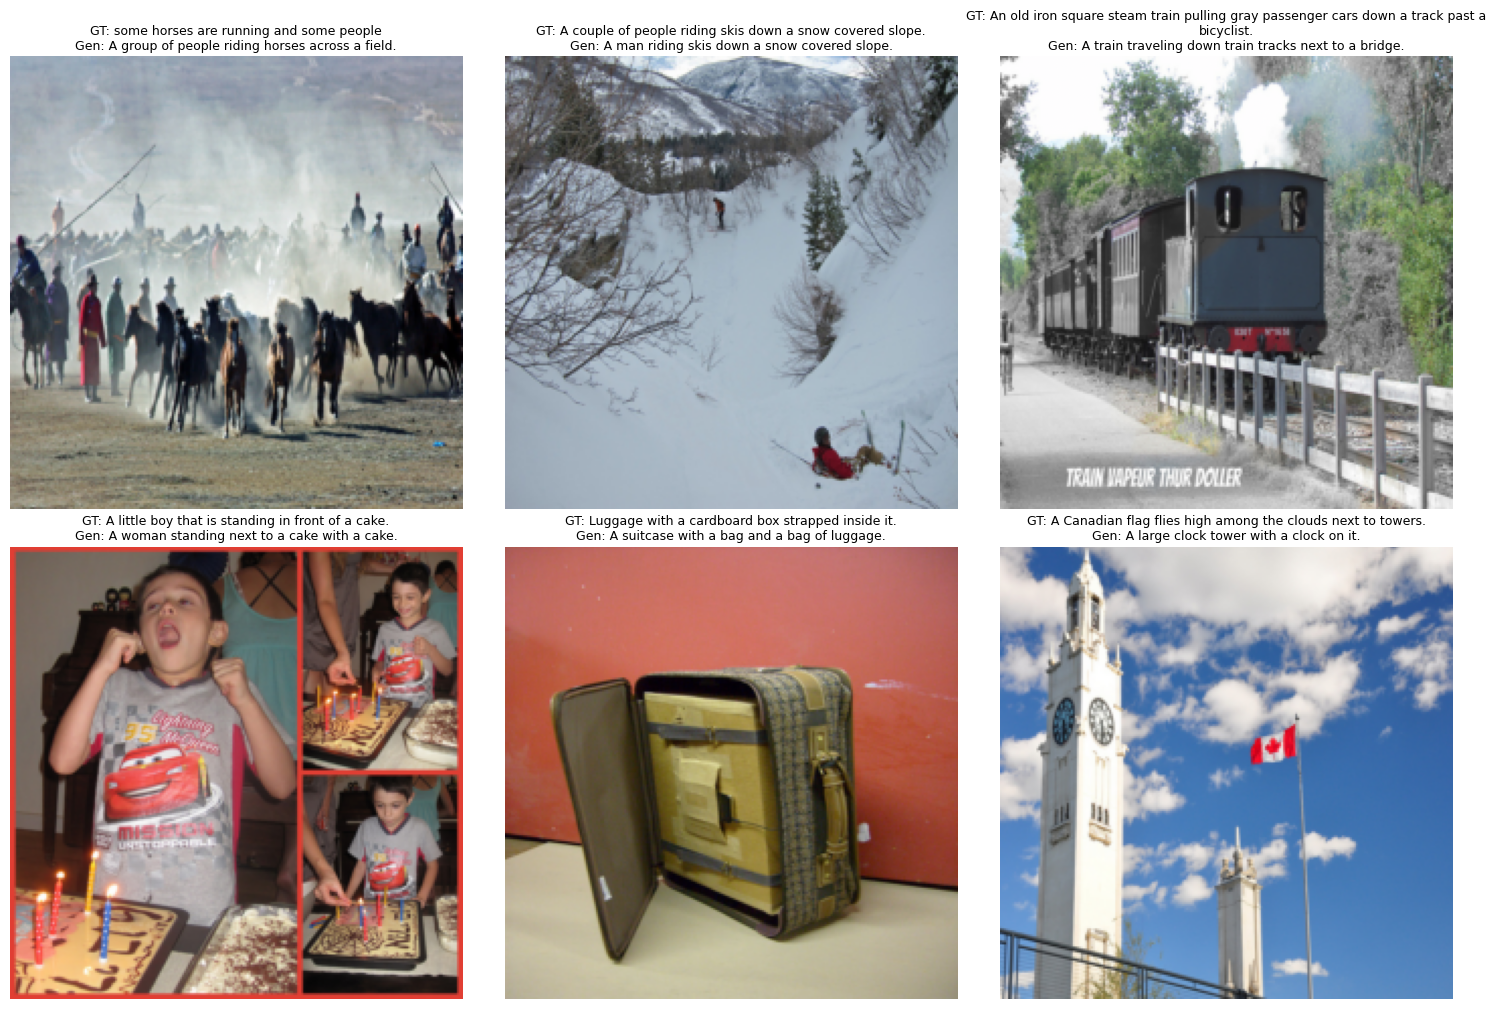

GPT2VL(
  (gpt2): GPT2(
    (embedding): Embedding(50258, 768)
    (position_embedding): AbsolutePositionEmbedding(
      (embedding): Embedding(128, 768)
    )
    (backbone): TransformerEncoder(
      (layers): ModuleList(
        (0-11): 12 x EncoderBlock(
          (self_attn): Multi_Head_Attention(
            (qkv_proj): Linear(in_features=768, out_features=2304, bias=True)
            (out_proj): Linear(in_features=768, out_features=768, bias=True)
          )
          (ffn): FF_GELU(
            (gelu): Sequential(
              (0): Linear(in_features=768, out_features=3072, bias=True)
              (1): GELU(approximate='none')
              (2): Dropout(p=0.1, inplace=False)
              (3): Linear(in_features=3072, out_features=768, bias=True)
              (4): Dropout(p=0.1, inplace=False)
            )
          )
          (norm1): LayerNorm()
          (norm2): LayerNorm()
        )
      )
      (final_norm): LayerNorm()
    )
    (lm_head): Linear(in_features=768,

In [18]:
import matplotlib.pyplot as plt

@torch.no_grad()
def generate_caption(model, tokenizer, image_tensor, device, max_new_tokens=40):
    """Greedy-decode a single caption for one preprocessed image tensor (C,H,W)."""
    model.eval()
    images = image_tensor.unsqueeze(0).to(device)
    visual_ctx = model.encode_image(images)  # (1, num_visual_tokens, C)

    bos_id = tokenizer.bos_token_id if tokenizer.bos_token_id is not None else tokenizer.eos_token_id
    eos_id = tokenizer.eos_token_id

    gen_ids = torch.full((1, 1), bos_id, dtype=torch.long, device=device)
    for _ in range(max_new_tokens):
        with torch.amp.autocast(device_type=device.type, dtype=torch.float16 if device.type == "cuda" else torch.float32):
            logits = model(gen_ids, visual_context=visual_ctx)
        next_tok = logits[:, -1, :].argmax(dim=-1, keepdim=True)
        gen_ids = torch.cat([gen_ids, next_tok], dim=1)
        if next_tok.item() == eos_id:
            break

    ids = gen_ids[0, 1:].tolist()
    if eos_id in ids:
        ids = ids[: ids.index(eos_id)]
    return tokenizer.decode(ids, skip_special_tokens=True)


# Reverse the ImageNet normalization used in OnTheFlyVisionTextDataset.transform
_IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
_IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def denormalize_for_display(img_tensor: torch.Tensor):
    img = img_tensor.detach().cpu() * _IMAGENET_STD + _IMAGENET_MEAN
    img = img.clamp(0, 1).permute(1, 2, 0).numpy()
    return img


# ---- Pick a few random samples from the held-out eval set ----
num_samples = 12
sample_indices = random.sample(range(len(eval_subset)), min(num_samples, len(eval_subset)))

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for ax, idx in zip(axes, sample_indices):
    sample = eval_subset[idx]
    img_tensor = sample["image"]
    gt_caption = sample["raw_caption"]

    generated = generate_caption(model, tokenizer, img_tensor, device)

    ax.imshow(denormalize_for_display(img_tensor))
    ax.axis("off")
    ax.set_title(f"GT: {gt_caption}\nGen: {generated}", fontsize=9, wrap=True)

plt.tight_layout()
plt.show()

model.train()